# 02 · Experten + Gating (Track B: SQI-gated Mixture of Experts)

**Bachelorarbeit: AF-Detektion in kontaktlosen Signalen · Nik Büttner · RWTH Aachen**

Dieses Notebook setzt die von Blaß gewünschte Architektur zusammen und wertet sie aus:

1. **Drei Experten** (cECG / PPG / BCG) liefern je eine fensterweise AF-Wahrscheinlichkeit.
2. Das **Gating-Netz** sagt aus den SQIs den Zuverlässigkeits-Fehler jeder Modalität
   vorher (Ziel aus dem GT-EKG, Bachelet-Stil) und macht daraus Gewichte.
3. **Gewichtete Fusion** → fensterweise AF-Entscheidung.

Alles läuft **leckagefrei**: patientenweise LOPO-CV (kein Patient in Train *und* Test),
Out-of-Fold-Experten-Outputs fürs Gate, und das GT-EKG fließt **nur** ins Trainings-Ziel
des Gates — nie in den Test-Pfad.

> **Voraussetzung:** `01_features_sqi.ipynb` wurde gelaufen (Feature-Tabelle liegt im
> `data/`-Ordner). Für die Reliability-Tabelle wird `neurokit2` benötigt (GT-R-Zacken);
> ohne neurokit2 greift ein einfacher Fallback-Detektor.


& c:\Users\sshuser\Documents\BA\.venv\Scripts\Activate.ps1

Start-Process -FilePath "c:\Users\sshuser\Documents\BA\.venv\Scripts\jupyter.exe" `
  -ArgumentList "notebook --no-browser --port=8888 --NotebookApp.token=mytoken" `
  -WindowStyle Hidden‚

## 1 · Imports, Pfade, Feature-Tabelle laden

In [10]:
import sys, os

# Set working directory to your project root
os.chdir('/home/nik/projects/BA')

# Add both root and src to path
sys.path.insert(0, '/home/nik/projects/BA')
sys.path.insert(0, '/home/nik/projects/BA/src')

In [11]:
import os, sys, glob
import numpy as np, pandas as pd

NB_DIR  = os.path.abspath('')
SRC_DIR = os.path.abspath(os.path.join(NB_DIR, '..', 'src'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import extract as E
import experts as X
import reliability as R
import gating as G
import fusion_cv as CV
import models as M

DATA_ROOT = 'data/patients/'
DATA_DIR  = 'results/'

# Feature-Tabelle aus Notebook 01 (jüngste features_sqi_*.csv nehmen)
feat_files = sorted(glob.glob(os.path.join(DATA_DIR, 'features_sqi_*.csv')), key=os.path.getmtime)
assert feat_files, 'Keine Feature-Tabelle gefunden — erst 01_features_sqi.ipynb laufen lassen.'
df = pd.read_csv(feat_files[-1])
df, y, groups = E.split_Xygroups(df)
print('Features:', df.shape, '·', feat_files[-1])

Features: (7107, 191) · results/features_sqi_cecg_cwt_af6b45.csv


## 2 · Reliability-Tabelle (GT-EKG-basiertes Gate-Ziel)

Berechnet je Fenster, wie treu jede Modalität den wahren Rhythmus abbildet. Das ist
das **Trainings-Ziel** des Gates (nur hier wird das GT-EKG genutzt). Wird gecached.

`target_metric='cosen_err'` ist das AF-passende Default-Ziel (Fehler im stärksten
AF-Diskriminator). Die Tabelle enthält zusätzlich `hr_err` (Bachelet-Vergleich) und
`drr_sd_err`, sodass das Ziel später ohne Neuberechnung umgeschaltet werden kann.

In [12]:
REL_CACHE = os.path.join(DATA_DIR, 'reliability_cosen.csv')

if os.path.exists(REL_CACHE):
    rel = pd.read_csv(REL_CACHE)
    print('Reliability-Cache geladen:', rel.shape)
else:
    rel = R.build_reliability_table(DATA_ROOT, target_metric='cosen_err', n_jobs=8)
    rel.to_csv(REL_CACHE, index=False)
    print('Reliability gespeichert:', REL_CACHE)

# Abdeckung: wie oft liefert jede Modalität überhaupt einen Rhythmus?
for m in ['cecg', 'ppg', 'bcg']:
    print(f'  {m}: gültig in {rel[f"rel_{m}_valid"].mean()*100:.0f}% der Fenster')
rel.head(3)

Reliability-Cache geladen: (4701, 17)
  cecg: gültig in 100% der Fenster
  ppg: gültig in 93% der Fenster
  bcg: gültig in 100% der Fenster


,rel_cecg_valid,rel_cecg_hr_err,rel_cecg_cosen_err,rel_cecg_drr_sd_err,rel_cecg_target,rel_ppg_valid,rel_ppg_hr_err,rel_ppg_cosen_err,rel_ppg_drr_sd_err,rel_ppg_target,rel_bcg_valid,rel_bcg_hr_err,rel_bcg_cosen_err,rel_bcg_drr_sd_err,rel_bcg_target,patient,win_idx
0,True,0.174376,1.862751,69.059301,1.862751,True,35.604124,0.402029,7.049572,0.402029,True,8.158750,0.045326,95.227211,0.045326,PAT001,0
1,True,0.809775,0.191751,12.053732,0.191751,True,48.535165,0.389507,94.636297,0.389507,True,5.223822,1.534347,165.864732,1.534347,PAT001,1
2,True,0.226654,0.328805,7.619548,0.328805,True,39.244175,0.220716,141.925745,0.220716,True,1.105909,1.411498,172.957288,1.411498,PAT001,2


## 3 · Experten solo (Sanity + Modalitäts-Story)

Out-of-Fold-AUC je Experte. Erwartung aus deinen bisherigen Ergebnissen: PPG trägt
das Signal, cECG mittel, BCG schwach. Das ist genau die Asymmetrie, die das Gate
ausnutzen soll.

In [13]:
from sklearn.metrics import roc_auc_score
oof = X.oof_expert_probs(df, y, groups, n_splits=5)
print('Out-of-Fold-AUC je Experte:')
for m in G.ORDER:
    print(f'  {m:5s}: {roc_auc_score(y, oof[f"p_{m}"]):.3f}')

Out-of-Fold-AUC je Experte:
  cecg : 0.810
  ppg  : 0.845
  bcg  : 0.856


In [14]:
# Experten-Schicht EINMAL je Fold berechnen (parallel) und über alle Gate-Varianten nutzen.
# Unabhängig von der Reliability-Tabelle -> der Stage-0-Rebuild invalidiert diesen Cache NICHT.
fold_cache = CV.precompute_folds(df, y, groups, inner_splits=5, random_state=42,
                                 n_jobs=-1, cache_dir=DATA_DIR)

Berechne Experten-Schicht für 40 Folds (sig=2509724b7e5485ce, n_jobs=-1) ...
  fertig in 47.6s · 40 Folds
  gespeichert: results/fold_expert_cache_2509724b7e5485ce.joblib


## 6 · Konfidenzintervalle der besten Konfiguration

Patienten-Cluster-Bootstrap (hält alle Fenster eines Patienten zusammen) — konsistent
zur Auswertung deiner bisherigen `window_nested`-Ergebnisse.

In [15]:
BEST_GATE   = 'gb'          # nach Tabelle in Abschnitt 4 wählen
BEST_TARGET = 'cosen_err'   # nach Tabelle in Abschnitt 5 wählen

m, t, yt, yp, yd, yg = CV.evaluate_moe(
    df, rel, y, groups, gate_kind=BEST_GATE, target_metric=BEST_TARGET,
    inner_splits=5, min_spec=0.80, return_arrays=True, fold_cache=fold_cache)

ci = M.bootstrap_ci(yt, yp, t, n_boot=2000, groups=yg)
print(f'Beste Konfiguration: gate={BEST_GATE}, target={BEST_TARGET}, threshold={t:.3f}\n')
for k in ['AUC', 'Sensitivität', 'Spezifität', 'Accuracy']:
    lo, hi = ci[k]
    print(f'  {k:12s}: {m[k]:.3f}  [{lo:.3f}, {hi:.3f}]')

Beste Konfiguration: gate=gb, target=cosen_err, threshold=0.481

  AUC         : 0.928  [0.870, 0.971]
  Sensitivität: 0.926  [0.880, 0.967]
  Spezifität  : 0.794  [0.678, 0.901]
  Accuracy    : 0.857  [0.793, 0.916]


In [16]:
# Stage 0.5 — sagt der SQI das Zuverlässigkeits-Ziel überhaupt voraus?
# Wurzel-Ursache für flache Gewichte: ohne SQI->Fehler-Zusammenhang kann KEINE
# Gewichtungskurve (Softmax oder Bachelet) die Fusion fensterweise steuern.
pv = CV.gate_predictive_validity(df, rel, y, groups,
                                 gate_kind=BEST_GATE, target_metric=BEST_TARGET)
print('Gate-Prädiktionsgüte (nur Fenster mit gültigem GT-Ziel):')
pv.round(3)

Gate-Prädiktionsgüte (nur Fenster mit gültigem GT-Ziel):


,r,rho,R2_vs_train_mean,n_valid
modality,,,,
cecg,-0.062,-0.055,-0.171,4695
ppg,0.073,0.050,-0.079,4381
bcg,0.015,0.014,-0.144,4699


## 7 · Adaptivität des Gates — Kernprüfung

Track B behauptet: die **fensterweise** SQI-Information steuert die Fusion. Diese
Prüfung trennt das in zwei Beiträge — eine feste, gelernte Modalitätsgewichtung
vs. die zusätzliche Pro-Fenster-Anpassung — und misst beide unabhängig:

- **`compare_adaptivity`**: `equal` (1/3 fix) → `*-fix` (gelerntes, eingefrorenes
  Mittelgewicht) → `*-win` (volles Pro-Fenster-Gate). Δ(fix→win) = was die
  fensterweise Steuerung *für die Metrik* bringt.
- **`gate_weight_report`**: misst, wie stark sich die Gewichte *innerhalb eines
  Patienten* bewegen (`std_within_patient`). ≈ 0 ⇒ das Gate reagiert nicht auf die
  fensterweise Signalqualität.3 

In [17]:
adt = CV.compare_adaptivity(df, rel, y, groups,
                            base_gate=BEST_GATE, target_metric=BEST_TARGET,
                            inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
acols = ['variant', 'AUC', 'Sensitivität', 'Spezifität', 'Accuracy', 'threshold']
adt[acols].round(3)

,variant,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.928,0.923,0.801,0.859,0.490
1,gb-fix,0.928,0.919,0.799,0.857,0.488
2,gb-win,0.928,0.926,0.794,0.857,0.481


In [18]:
rep, W = CV.gate_weight_report(df, rel, y, groups,
                               gate_kind=BEST_GATE, target_metric=BEST_TARGET,
                               inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
print('Wie stark bewegt das Gate seine Gewichte? (std_within_patient ist der Kernwert)')
rep.round(3)

Wie stark bewegt das Gate seine Gewichte? (std_within_patient ist der Kernwert)


,mean_weight,std_overall,std_within_patient,cv_within_patient
cecg,0.335,0.045,0.038,0.113
ppg,0.353,0.056,0.041,0.117
bcg,0.312,0.053,0.041,0.130


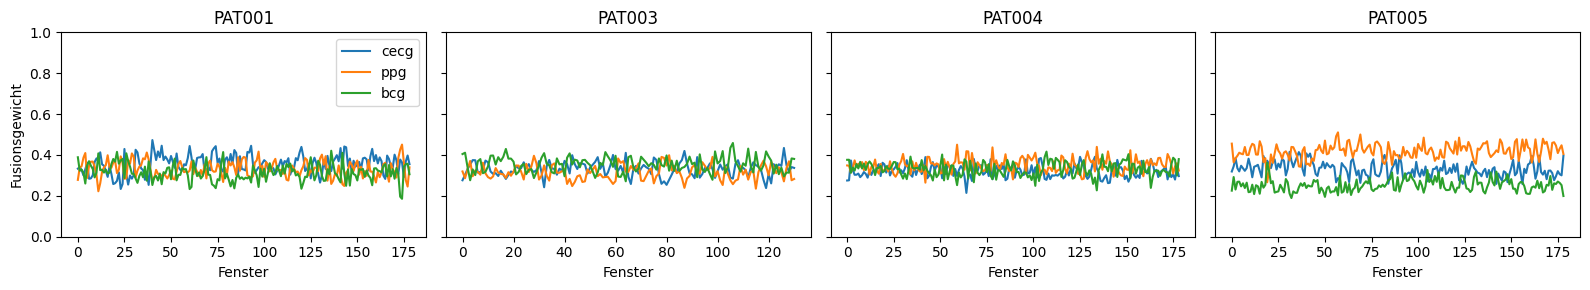

In [19]:
import matplotlib.pyplot as plt
ex = list(pd.unique(W['patient']))[:4]            # vier Beispiel-Patienten
fig, axes = plt.subplots(1, len(ex), figsize=(4 * len(ex), 3), sharey=True)
for ax, pid in zip(np.atleast_1d(axes), ex):
    sub = W[W['patient'] == pid]
    for m in G.ORDER:
        ax.plot(range(len(sub)), sub[f'w_{m}'].values, label=m)
    ax.set_title(pid); ax.set_xlabel('Fenster'); ax.set_ylim(0, 1)
np.atleast_1d(axes)[0].set_ylabel('Fusionsgewicht'); np.atleast_1d(axes)[0].legend()
plt.tight_layout(); plt.show()

In [20]:
XGB_CLF = {'cecg': 'XGB', 'ppg': 'XGB', 'bcg': 'XGB'}

# Cache ist nach clf verschlüsselt -> für XGB neu bauen (eigene Datei, LR-Cache bleibt)
fold_cache_xgb = CV.precompute_folds(df, y, groups, clf_per_modality=XGB_CLF,
                                     inner_splits=5, random_state=42,
                                     n_jobs=-1, cache_dir=DATA_DIR)

# Pro-Experte OOF-AUC mit XGB  (vs. LR: cECG 0.787 / PPG 0.884 / BCG 0.680)
from sklearn.metrics import roc_auc_score
oof_xgb = X.oof_expert_probs(df, y, groups, clf_per_modality=XGB_CLF, n_splits=5)
for m in G.ORDER:
    print(f'  {m:5s}: OOF-AUC = {roc_auc_score(y, oof_xgb[f"p_{m}"]):.3f}')

# Fusions-Vergleich mit XGB-Experten (inkl. xgb-Gate aus Schritt 1)
tab_xgb = CV.compare_gates(df, rel, y, groups, gate_kinds=('equal','gb','xgb'),
                           clf_per_modality=XGB_CLF, inner_splits=5, min_spec=0.80,
                           fold_cache=fold_cache_xgb)
tab_xgb[['gate','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3)

Berechne Experten-Schicht für 40 Folds (sig=e8f2a7f042404f90, n_jobs=-1) ...
  fertig in 63.4s · 40 Folds
  gespeichert: results/fold_expert_cache_e8f2a7f042404f90.joblib
  cecg : OOF-AUC = 0.873
  ppg  : OOF-AUC = 0.804
  bcg  : OOF-AUC = 0.862


,gate,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.919,0.873,0.806,0.838,0.492
1,gb,0.918,0.878,0.807,0.841,0.487
2,xgb,0.918,0.877,0.802,0.838,0.488


In [21]:
for tm in ['cosen_err', 'drr_sd_err', 'hr_err']:
    pv = CV.gate_predictive_validity(df, rel, y, groups, gate_kind='xgb', target_metric=tm)
    print(f'\nZiel = {tm}\n{pv.round(3).to_string()}')


Ziel = cosen_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg     -0.078 -0.076            -0.115     4695
ppg       0.075  0.051            -0.028     4381
bcg      -0.003 -0.007            -0.087     4699

Ziel = drr_sd_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg     -0.107 -0.084            -0.120     4695
ppg      -0.007  0.026            -0.092     4381
bcg       0.104  0.070            -0.027     4699

Ziel = hr_err
              r    rho  R2_vs_train_mean  n_valid
modality                                         
cecg     -0.091 -0.089            -0.148     4695
ppg       0.146  0.172             0.038     4381
bcg       0.101  0.143            -0.062     4699


In [22]:
MIX_CLF = {'cecg': 'XGB', 'ppg': 'LR', 'bcg': 'XGB'}
fold_cache_mix = CV.precompute_folds(df, y, groups, clf_per_modality=MIX_CLF,
                                     inner_splits=5, random_state=42, n_jobs=-1, cache_dir=DATA_DIR)
tab_mix = CV.compare_gates(df, rel, y, groups, gate_kinds=('equal','gb'),
                           clf_per_modality=MIX_CLF, inner_splits=5, min_spec=0.80,
                           fold_cache=fold_cache_mix)
tab_mix[['gate','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3)

Berechne Experten-Schicht für 40 Folds (sig=4097df20304edcf5, n_jobs=-1) ...
  fertig in 58.4s · 40 Folds
  gespeichert: results/fold_expert_cache_4097df20304edcf5.joblib


,gate,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.937,0.924,0.807,0.863,0.466
1,gb,0.936,0.927,0.808,0.865,0.462


In [23]:
# dRR-SD-Ziel: AF-Fusion ~ wie CoSEn (0.936 vs 0.937), aber SQI sagt es BESSER vorher
# (cECG r~0.45). Bringt die FENSTERWEISE Steuerung damit endlich etwas (gb-win > gb-fix)?
adt_drr = CV.compare_adaptivity(df, rel, y, groups, base_gate='gb', target_metric='drr_sd_err',
                                inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
print(adt_drr[['variant','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3).to_string(index=False))

rep_drr, _ = CV.gate_weight_report(df, rel, y, groups, gate_kind='gb', target_metric='drr_sd_err',
                                   inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
print('\n', rep_drr.round(3).to_string())

variant   AUC  Sensitivität  Spezifität  Accuracy  threshold
  equal 0.928         0.923       0.801     0.859      0.490
 gb-fix 0.930         0.915       0.795     0.852      0.477
 gb-win 0.930         0.923       0.793     0.855      0.464

       mean_weight  std_overall  std_within_patient  cv_within_patient
cecg        0.271        0.055               0.046              0.171
ppg         0.422        0.052               0.043              0.103
bcg         0.307        0.052               0.040              0.131


In [24]:
# #1+#2: stärkere + kalibrierte Experten -> eigener Fold-Cache (Signatur enthält +cal)
MIX = {'cecg': 'XGB+cal', 'ppg': 'LR+cal', 'bcg': 'XGB+cal'}
fold_cache_mix = CV.precompute_folds(df, y, groups, clf_per_modality=MIX,
                                     inner_splits=5, random_state=42, n_jobs=-1,
                                     cache_dir=DATA_DIR)

from sklearn.metrics import roc_auc_score
oof_mix = X.oof_expert_probs(df, y, groups, clf_per_modality=MIX, n_splits=5)
for m in G.ORDER:                       # gegen LR: cECG 0.787 / PPG 0.884 / BCG 0.680
    print(f'  {m:5s}: OOF-AUC = {roc_auc_score(y, oof_mix[f"p_{m}"]):.3f}')

Berechne Experten-Schicht für 40 Folds (sig=4ce6822f11c79bab, n_jobs=-1) ...


  fertig in 119.1s · 40 Folds
  gespeichert: results/fold_expert_cache_4ce6822f11c79bab.joblib
  cecg : OOF-AUC = 0.857
  ppg  : OOF-AUC = 0.854
  bcg  : OOF-AUC = 0.864


Fazit: stacked ≈ equal — Fusion gesättigt, der PPG-Experte (~0.87) ist die Decke.

In [25]:
# #3: gewichtete vs. gestapelte Fusion auf denselben Experten/Folds
fus = CV.compare_fusion(df, rel, y, groups, clf_per_modality=MIX,
                        weighted_gates=('equal', 'torch_mlp'),   # torch_mlp braucht gate_params=best_torch + target_metric
                        stack_clfs=('logreg', 'gb'),
                        inner_splits=5, min_spec=0.80, fold_cache=fold_cache_mix)
fus.round(3)

/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


,fusion,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,weighted:equal,0.933,0.905,0.815,0.858,0.483
1,weighted:torch_mlp,0.932,0.904,0.818,0.859,0.482
2,stacked:logreg,0.934,0.909,0.819,0.862,0.412
3,stacked:gb,0.919,0.939,0.758,0.845,0.313


## Nächste Schritte

- **Klassifikator je Experte** variieren: `clf_per_modality={'cecg':'RF','ppg':'LR','bcg':'GB'}`
  an `compare_gates`/`evaluate_moe` übergeben.
- **Gate als echtes KNN** (PyTorch + Optuna) wie bei Bachelet — der sklearn-`mlp`
  ist der Einstieg; die Schnittstelle (`gating.make_gate`) bleibt gleich.
- **Erklärbarkeit**: zeigen, wovon das Gate seine Gewichte ableitet (welche SQIs
  treiben das vorhergesagte Vertrauen?) — Integrated Gradients / Permutation Importance.

**Mit Blaß bestätigen:**
1. Gate-Ziel = RR-Irregularitäts-Treue (CoSEn), nicht reiner HR-Fehler — passt das zu AF?
2. Kanal-Aggregation PPG/BCG = bester Kanal (kleinster Fehler) — oder Mittelwert?
3. Experten eingefroren, Gate darüber trainiert (B/Stacking) — wie besprochen.


In [26]:
# GT-Detektor-Güte je Fenster (Konsens mehrerer R-Zacken-Detektoren). Einmalig, gecacht.
GTQ_CACHE = os.path.join(DATA_DIR, 'gt_quality.csv')
if os.path.exists(GTQ_CACHE):
    gtq = pd.read_csv(GTQ_CACHE); print('GT-Güte-Cache geladen:', gtq.shape)
else:
    gtq = R.build_gt_quality_table(DATA_ROOT, n_jobs=8)
    gtq.to_csv(GTQ_CACHE, index=False)

print('\nGlobale GT-conf-Verteilung:')
print(gtq['gt_conf'].describe(percentiles=[.1,.25,.5,.75,.9]).round(3))
print('\nPro-Patient (schlechteste GT zuerst):')
print(R.summarize_gt_quality(gtq, conf_lo=0.80).round(3).head(12).to_string())

GT-Güte-Cache geladen: (4701, 7)

Globale GT-conf-Verteilung:
count    4701.000
mean        0.654
std         0.219
min         0.030
10%         0.342
25%         0.461
50%         0.713
75%         0.829
90%         0.906
max         1.000
Name: gt_conf, dtype: float64

Pro-Patient (schlechteste GT zuerst):
         gt_conf_mean  frac_low_conf  frac_no_strong  n_windows
patient                                                        
PAT028          0.252          1.000             0.0        119
PAT006          0.294          1.000             0.0         96
PAT008          0.336          1.000             0.0        119
PAT017          0.348          1.000             0.0        119
PAT038          0.419          1.000             0.0        119
PAT004          0.432          1.000             0.0        119
PAT023          0.448          1.000             0.0        119
PAT043          0.450          0.798             0.0        119
PAT045          0.451          1.000             

In [27]:
# Ist der scheinbare Detektor-Fehler ECHT oder nur ein GT-Problem?
rel_q = rel.merge(gtq[['patient','win_idx','gt_conf']], on=['patient','win_idx'], how='left')
hi = rel_q['gt_conf'] >= 0.80
print(f'Fenster mit vertrauenswürdiger GT (gt_conf>=0.80): {hi.mean()*100:.0f}%\n')
for m in ['cecg','ppg','bcg']:
    e = rel_q[f'rel_{m}_hr_err']
    v = (rel_q[f'rel_{m}_valid'] == True)
    print(f'  {m:5s}: median hr_err  GT-gut={e[v & hi].median():6.2f} bpm  |  '
          f'GT-schlecht={e[v & ~hi].median():6.2f} bpm  (valid={v.mean()*100:.0f}%)')

Fenster mit vertrauenswürdiger GT (gt_conf>=0.80): 31%

  cecg : median hr_err  GT-gut=  2.04 bpm  |  GT-schlecht=  1.59 bpm  (valid=100%)
  ppg  : median hr_err  GT-gut=  1.47 bpm  |  GT-schlecht=  1.28 bpm  (valid=93%)
  bcg  : median hr_err  GT-gut=  6.41 bpm  |  GT-schlecht=  5.79 bpm  (valid=100%)


In [28]:
GTQ_CACHE = os.path.join(DATA_DIR, 'gt_quality.csv')   # alte Datei vorher löschen!
gtq = R.build_gt_quality_table(DATA_ROOT, n_jobs=8)
gtq.to_csv(GTQ_CACHE, index=False)
print('\nGT-conf (nur starke Detektoren):')
print(gtq['gt_conf'].describe(percentiles=[.1,.25,.5,.75,.9]).round(3))
if 'gt_fallback_agree' in gtq.columns:
    print(
        'Median Fallback-Übereinstimmung:',
        round(gtq['gt_fallback_agree'].median(), 3)
    )
else:
    print("Spalte 'gt_fallback_agree' nicht vorhanden.")
print('\nPro-Patient (schlechteste GT zuerst):')
print(R.summarize_gt_quality(gtq, conf_lo=0.80).round(3).head(12).to_string())

  PAT001: 119 Fenster
  PAT003: 87 Fenster
  PAT004: 119 Fenster
  PAT005: 119 Fenster
  PAT006: 96 Fenster
  PAT007: 119 Fenster
  PAT008: 119 Fenster
  PAT009: 119 Fenster
  PAT010: 119 Fenster
  PAT011: 119 Fenster
  PAT012: 119 Fenster
  PAT013: 119 Fenster
  PAT014: 119 Fenster
  PAT015: 119 Fenster
  PAT016: 119 Fenster
  PAT017: 119 Fenster
  PAT018: 119 Fenster
  PAT019: 119 Fenster
  PAT021: 119 Fenster
  PAT022: 119 Fenster
  PAT023: 119 Fenster
  PAT024: 119 Fenster
  PAT025: 119 Fenster
  PAT026: 119 Fenster
  PAT028: 119 Fenster
  PAT029: 115 Fenster
  PAT030: 119 Fenster
  PAT031: 119 Fenster
  PAT033: 119 Fenster
  PAT034: 119 Fenster
  PAT036: 119 Fenster
  PAT037: 119 Fenster
  PAT038: 119 Fenster
  PAT039: 119 Fenster
  PAT040: 119 Fenster
  PAT041: 119 Fenster
  PAT042: 119 Fenster
  PAT043: 119 Fenster
  PAT044: 119 Fenster
  PAT045: 119 Fenster
  gesamt 4701 Fenster · GT-conf (stark) Median 0.766 · Fallback-Übereinst. Median 0.822 · 0% Fenster mit < 2 starken Detek

In [29]:
rel_q = rel.merge(gtq[['patient','win_idx','gt_conf']], on=['patient','win_idx'], how='left')
hi = rel_q['gt_conf'] >= 0.80
print(f'Fenster mit vertrauenswürdiger GT (gt_conf>=0.80): {hi.mean()*100:.0f}%\n')
for m in ['cecg','ppg','bcg']:
    v  = (rel_q[f'rel_{m}_valid'] == True)
    he = rel_q[f'rel_{m}_hr_err']; ce = rel_q[f'rel_{m}_cosen_err']
    print(f'  {m:5s}  hr_err  gut={he[v&hi].median():5.2f} | schlecht={he[v&~hi].median():5.2f}    '
          f'cosen_err  gut={ce[v&hi].median():6.3f} | schlecht={ce[v&~hi].median():6.3f}')

Fenster mit vertrauenswürdiger GT (gt_conf>=0.80): 41%

  cecg   hr_err  gut= 2.88 | schlecht= 1.04    cosen_err  gut= 0.925 | schlecht= 0.926
  ppg    hr_err  gut= 1.51 | schlecht= 1.22    cosen_err  gut= 0.719 | schlecht= 0.617
  bcg    hr_err  gut= 6.26 | schlecht= 5.79    cosen_err  gut= 0.866 | schlecht= 0.898


In [30]:
# torch_mlp-Gate mit Optuna abstimmen (Bachelet 3.7.3, AF-Ziel statt HF).
# Ziel = drr_sd_err: AF-relevant und vom SQI am besten vorhergesagt.
best_torch, study = CV.tune_torch_gate(
    df, rel, y, groups,
    target_metric='drr_sd_err',
    n_trials=100, cv_splits=5, random_state=42, n_jobs=1)   # n_jobs hochsetzen: vorher torch.set_num_threads(1)
best_torch

[I 2026-06-12 14:02:38,511] A new study created in memory with name: no-name-628b6826-fce9-470a-9d0b-df44a380ce8e
[I 2026-06-12 14:02:42,528] Trial 0 finished with value: 121.272629463196 and parameters: {'hidden_dims': '128', 'lr': 0.00019811507008137995, 'weight_decay': 4.102220837686793e-05, 'batch_size': 64, 'max_epochs': 31, 'patience': 59, 'dropout': 0.2497327922401265}. Best is trial 0 with value: 121.272629463196.
[I 2026-06-12 14:03:16,832] Trial 1 finished with value: 136.17752520173764 and parameters: {'hidden_dims': '256,128', 'lr': 0.000996916331437621, 'weight_decay': 0.0001461907967182581, 'batch_size': 64, 'max_epochs': 232, 'patience': 32, 'dropout': 0.23555278841790406}. Best is trial 0 with value: 121.272629463196.


[I 2026-06-12 14:03:27,852] Trial 2 finished with value: 137.98773617630565 and parameters: {'hidden_dims': '128,64', 'lr': 0.0014328889195082965, 'weight_decay': 4.386097111328736e-05, 'batch_size': 128, 'max_epochs': 196, 'patience': 13, 'dropout': 0.20526990795364705}. Best is trial 0 with value: 121.272629463196.
[I 2026-06-12 14:04:05,045] Trial 3 finished with value: 142.89868955474384 and parameters: {'hidden_dims': '128,64', 'lr': 0.0053767340092928375, 'weight_decay': 6.585518268847226e-05, 'batch_size': 32, 'max_epochs': 127, 'patience': 59, 'dropout': 0.23253984700833435}. Best is trial 0 with value: 121.272629463196.
[I 2026-06-12 14:04:35,481] Trial 4 finished with value: 132.87769457507866 and parameters: {'hidden_dims': '64', 'lr': 0.000147370037685957, 'weight_decay': 4.931689442897474e-05, 'batch_size': 128, 'max_epochs': 501, 'patience': 26, 'dropout': 0.08428035290621423}. Best is trial 0 with value: 121.272629463196.
[I 2026-06-12 14:04:50,253] Trial 5 finished with

offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 178  final_offset = 145
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 329  final_offset = 224
  trim_start_s   = 0.00  trim_end_s = 0.00
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': True, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = False
  initial_offset = 233  final_offset = 126
  trim_start_s   = 0.00  trim_end_s = 0.00
  flipped cecg
offset_correction: loaded alignment.json  [supersedes all]
  flips          = {'cecg': False, 'ppg1': False, 'ppg2': False, 'bcg1': False, 'bcg2': False}
  gt_flipped     = True
  initial_off

[I 2026-06-12 14:07:48,952] Trial 17 finished with value: 128.14466985362836 and parameters: {'hidden_dims': '128', 'lr': 0.00019119092506197563, 'weight_decay': 0.0011662558125326585, 'batch_size': 64, 'max_epochs': 171, 'patience': 45, 'dropout': 0.1989906194768452}. Best is trial 12 with value: 121.06348397484638.
[I 2026-06-12 14:08:00,378] Trial 18 finished with value: 132.69607925702218 and parameters: {'hidden_dims': '64', 'lr': 0.0019111589277629756, 'weight_decay': 0.0003530169921842472, 'batch_size': 64, 'max_epochs': 80, 'patience': 53, 'dropout': 0.2700644510349014}. Best is trial 12 with value: 121.06348397484638.
[I 2026-06-12 14:08:39,684] Trial 19 finished with value: 139.17342807780105 and parameters: {'hidden_dims': '256,128', 'lr': 0.0001626533209742007, 'weight_decay': 0.00038785799892981703, 'batch_size': 256, 'max_epochs': 314, 'patience': 25, 'dropout': 0.09610192057737499}. Best is trial 12 with value: 121.06348397484638.
[I 2026-06-12 14:09:23,192] Trial 20 fin

Beste Val-SmoothL1: 120.6550  ·  beste Params: {'hidden_dims': (128,), 'lr': 0.0001474642287913027, 'weight_decay': 0.0008036259969452718, 'batch_size': 64, 'max_epochs': 42, 'patience': 38, 'dropout': 0.004440189192759375}


{'hidden_dims': (128,),
 'lr': 0.0001474642287913027,
 'weight_decay': 0.0008036259969452718,
 'batch_size': 64,
 'max_epochs': 42,
 'patience': 38,
 'dropout': 0.004440189192759375}

In [31]:
# torch_mlp gegen equal/gb — Experten-Schicht aus fold_cache wiederverwendet.
# target_metric muss zur Abstimmung passen (drr_sd_err).
tab_torch = CV.compare_gates(
    df, rel, y, groups,
    gate_kinds=('equal', 'gb', 'torch_mlp'),
    target_metric='drr_sd_err',
    gate_params=best_torch,                 # wirkt nur aufs torch_mlp; gb/equal ignorieren es
    inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
tab_torch[['gate','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3)

,gate,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.928,0.923,0.801,0.859,0.490
1,gb,0.930,0.923,0.793,0.855,0.464
2,torch_mlp,0.930,0.921,0.789,0.852,0.464


In [32]:
best_torch, study = CV.tune_torch_gate(
    df, rel, y, groups,
    target_metric='drr_sd_err',
    n_trials=100, cv_splits=5, random_state=42, n_jobs=1)

# Save immediately after tuning
import pickle
with open('results/best_torch.pkl', 'wb') as f:
    pickle.dump(best_torch, f)
print("best_torch saved ✅")

tab_torch = CV.compare_gates(
    df, rel, y, groups,
    gate_kinds=('equal', 'gb', 'torch_mlp'),
    target_metric='drr_sd_err',
    gate_params=best_torch,
    inner_splits=5, min_spec=0.80, fold_cache=fold_cache)

# Save the results table too
tab_torch.to_csv('results/tab_torch_results.csv', index=False)
print("tab_torch saved ✅")

tab_torch[['gate','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3)

[I 2026-06-12 14:26:29,850] A new study created in memory with name: no-name-d80ec268-e9b6-42dc-a473-8945f9f9bfaa
[I 2026-06-12 14:26:33,861] Trial 0 finished with value: 121.272629463196 and parameters: {'hidden_dims': '128', 'lr': 0.00019811507008137995, 'weight_decay': 4.102220837686793e-05, 'batch_size': 64, 'max_epochs': 31, 'patience': 59, 'dropout': 0.2497327922401265}. Best is trial 0 with value: 121.272629463196.
[I 2026-06-12 14:27:08,134] Trial 1 finished with value: 136.17752520173764 and parameters: {'hidden_dims': '256,128', 'lr': 0.000996916331437621, 'weight_decay': 0.0001461907967182581, 'batch_size': 64, 'max_epochs': 232, 'patience': 32, 'dropout': 0.23555278841790406}. Best is trial 0 with value: 121.272629463196.


[I 2026-06-12 14:27:19,156] Trial 2 finished with value: 137.98773617630565 and parameters: {'hidden_dims': '128,64', 'lr': 0.0014328889195082965, 'weight_decay': 4.386097111328736e-05, 'batch_size': 128, 'max_epochs': 196, 'patience': 13, 'dropout': 0.20526990795364705}. Best is trial 0 with value: 121.272629463196.
[I 2026-06-12 14:27:56,268] Trial 3 finished with value: 142.89868955474384 and parameters: {'hidden_dims': '128,64', 'lr': 0.0053767340092928375, 'weight_decay': 6.585518268847226e-05, 'batch_size': 32, 'max_epochs': 127, 'patience': 59, 'dropout': 0.23253984700833435}. Best is trial 0 with value: 121.272629463196.
[I 2026-06-12 14:28:26,748] Trial 4 finished with value: 132.87769457507866 and parameters: {'hidden_dims': '64', 'lr': 0.000147370037685957, 'weight_decay': 4.931689442897474e-05, 'batch_size': 128, 'max_epochs': 501, 'patience': 26, 'dropout': 0.08428035290621423}. Best is trial 0 with value: 121.272629463196.
[I 2026-06-12 14:28:41,534] Trial 5 finished with

Beste Val-SmoothL1: 120.6550  ·  beste Params: {'hidden_dims': (128,), 'lr': 0.0001474642287913027, 'weight_decay': 0.0008036259969452718, 'batch_size': 64, 'max_epochs': 42, 'patience': 38, 'dropout': 0.004440189192759375}
best_torch saved ✅
tab_torch saved ✅


,gate,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.928,0.923,0.801,0.859,0.490
1,gb,0.930,0.923,0.793,0.855,0.464
2,torch_mlp,0.930,0.921,0.789,0.852,0.464


In [33]:
import pickle, pandas as pd
best_torch = pickle.load(open('results/best_torch.pkl', 'rb'))
tab_torch = pd.read_csv('results/tab_torch_results.csv')
tab_torch[['gate','AUC','Sensitivität','Spezifität','Accuracy','threshold']].round(3)

,gate,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,equal,0.928,0.923,0.801,0.859,0.490
1,gb,0.930,0.923,0.793,0.855,0.464
2,torch_mlp,0.930,0.921,0.789,0.852,0.464


Fazit: fix > win — fensterweises SQI-Gating bringt nichts (bestätigt).

In [34]:
# 1) Adaptivität: schlägt die FENSTERWEISE Variante ihre eigene eingefrorene Mittelung?
adt_torch = CV.compare_adaptivity(df, rel, y, groups, base_gate='torch_mlp',
    target_metric='drr_sd_err', gate_params=best_torch,
    inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
print(adt_torch[['variant','AUC','Sensitivität','Spezifität','Accuracy']].round(3).to_string(index=False))

# 2) Bewegt das Gate die Gewichte überhaupt? (std_within_patient = Kernwert)
rep_t, _ = CV.gate_weight_report(df, rel, y, groups, gate_kind='torch_mlp',
    target_metric='drr_sd_err', gate_params=best_torch,
    inner_splits=5, min_spec=0.80, fold_cache=fold_cache)
print(rep_t.round(3).to_string())

      variant   AUC  Sensitivität  Spezifität  Accuracy
        equal 0.928         0.923       0.801     0.859
torch_mlp-fix 0.930         0.915       0.796     0.853
torch_mlp-win 0.930         0.921       0.789     0.852
      mean_weight  std_overall  std_within_patient  cv_within_patient
cecg        0.283        0.055               0.038              0.135
ppg         0.421        0.047               0.030              0.071
bcg         0.296        0.052               0.031              0.105


In [35]:
# PPG ist die Decke (~0.87) -> direkt tunen. n_jobs hochsetzen ist hier sicher (kein torch).
best_ppg, study_ppg = X.tune_expert(df, y, groups, 'ppg', clf='LR',
                                    n_trials=80, cv_splits=5, n_jobs=8)

[I 2026-06-12 14:49:47,938] A new study created in memory with name: no-name-45909fef-1e00-40ee-a3d9-5c2eba8d06c7
[I 2026-06-12 14:49:52,276] Trial 2 finished with value: 0.8522206130248499 and parameters: {'C': 0.0012288770033527774}. Best is trial 2 with value: 0.8522206130248499.
[I 2026-06-12 14:49:52,366] Trial 7 finished with value: 0.857304581705489 and parameters: {'C': 0.05679028816621048}. Best is trial 7 with value: 0.857304581705489.
[I 2026-06-12 14:49:52,431] Trial 3 finished with value: 0.8439756189141312 and parameters: {'C': 1.1391412851939833}. Best is trial 7 with value: 0.857304581705489.
[I 2026-06-12 14:49:52,519] Trial 1 finished with value: 0.8330023687258364 and parameters: {'C': 35.92880487854465}. Best is trial 7 with value: 0.857304581705489.
[I 2026-06-12 14:49:52,613] Trial 0 finished with value: 0.8370589267764413 and parameters: {'C': 5.53873657128236}. Best is trial 7 with value: 0.857304581705489.
[I 2026-06-12 14:49:52,676] Trial 5 finished with value

[I 2026-06-12 14:50:19,418] Trial 48 finished with value: 0.8582385985827001 and parameters: {'C': 0.012602747389766338}. Best is trial 48 with value: 0.8582385985827001.
[I 2026-06-12 14:50:19,633] Trial 51 finished with value: 0.8582067796405745 and parameters: {'C': 0.011796373317346778}. Best is trial 48 with value: 0.8582385985827001.
[I 2026-06-12 14:50:19,692] Trial 49 finished with value: 0.8581688508267689 and parameters: {'C': 0.010875053097901568}. Best is trial 48 with value: 0.8582385985827001.
[I 2026-06-12 14:50:19,738] Trial 52 finished with value: 0.8581546473588374 and parameters: {'C': 0.013751779854299161}. Best is trial 48 with value: 0.8582385985827001.
[I 2026-06-12 14:50:19,754] Trial 50 finished with value: 0.8581899576562089 and parameters: {'C': 0.012167939496418829}. Best is trial 48 with value: 0.8582385985827001.
[I 2026-06-12 14:50:19,841] Trial 54 finished with value: 0.858102118332186 and parameters: {'C': 0.009546389248317128}. Best is trial 48 with va

ppg LR: beste OOF-AUC = 0.858 · Params: {'C': 0.012602747389766338}


In [36]:
# Getunten PPG einsetzen (Tupel-Form), cECG/BCG als bestes Modell + Kalibrierung
MIX_T = {'cecg': 'XGB+cal', 'ppg': ('LR+cal', best_ppg), 'bcg': 'XGB+cal'}
fold_cache_t = CV.precompute_folds(df, y, groups, clf_per_modality=MIX_T,
                                   inner_splits=5, random_state=42, n_jobs=-1, cache_dir=DATA_DIR)

from sklearn.metrics import roc_auc_score
oof_t = X.oof_expert_probs(df, y, groups, clf_per_modality=MIX_T, n_splits=5)
for m in G.ORDER:                       # PPG vs. vorher 0.872
    print(f'  {m:5s}: OOF-AUC = {roc_auc_score(y, oof_t[f"p_{m}"]):.3f}')

CV.compare_fusion(df, rel, y, groups, clf_per_modality=MIX_T,
                  weighted_gates=('equal',), stack_clfs=('logreg',),
                  inner_splits=5, fold_cache=fold_cache_t).round(3)

Berechne Experten-Schicht für 40 Folds (sig=4200fa038d3d3bf4, n_jobs=-1) ...


  fertig in 117.1s · 40 Folds
  gespeichert: results/fold_expert_cache_4200fa038d3d3bf4.joblib
  cecg : OOF-AUC = 0.857
  ppg  : OOF-AUC = 0.865
  bcg  : OOF-AUC = 0.864


,fusion,AUC,Sensitivität,Spezifität,Accuracy,threshold
0,weighted:equal,0.934,0.906,0.815,0.859,0.487
1,stacked:logreg,0.937,0.919,0.814,0.864,0.396
